# Etapa Exploratória: Poluente x Internações Respiratórias

Este notebook implementa uma análise **univariada para séries temporais diárias** entre um poluente atmosférico e a série de internações respiratórias, com foco em **efeitos contemporâneos e defasados**.

## 1. Objetivo e cautelas metodológicas
- Investigar sinais de associação entre a exposição ambiental e `num_internacoes`.
- Avaliar o comportamento do poluente no **mesmo dia** (`lag0`), em **lags simples** (`lag1..lagMAX`) e em **médias móveis defasadas**.
- Calcular correlações de **Pearson** e **Spearman**.
- Produzir visualizações para apoiar a interpretação dos achados.

> **Cautela:** esta etapa é exploratória e preparatória para modelagem. Em séries temporais, correlações podem refletir sazonalidade, tendência e autocorrelação. **Correlação não implica causalidade.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


## 2. Configurações iniciais

Nesta seção, definimos as fontes de dados, as colunas relevantes, o poluente a ser analisado e os principais parâmetros da etapa de correlação.


In [2]:
# Caminhos das bases
AIR_QUALITY_URL = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/DailyQualiarRj/serie_diaria_qualidade_ar_rio_de_janeiro.parquet"
HOSPITALIZATION_URL = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

# Colunas de data
AIR_DATE_COLUMN = "data"
HOSP_DATE_COLUMN = "data_dia"
STANDARD_DATE_COLUMN = "data"

# Variáveis de interesse
TARGET_COLUMN = "num_internacoes"
ATMOSPHERIC_VARIABLE = "o3"

# Parâmetros da análise temporal
MAX_LAG = 14
MOVING_AVERAGE_WINDOWS = [3, 7, 14, 21, 30, 60, 90, 120, 150]
SHIFTS = [1, 7, 14, 21]
MIN_OBS_FOR_CORR = 30
TOP_FEATURES_TO_PLOT = 3
FIG_DPI = 120
ROLLING_MEAN_WINDOW = 30

print(f"Variável resposta: {TARGET_COLUMN}")
print(f"Variável atmosférica: {ATMOSPHERIC_VARIABLE}")
print(f"Máximo lag avaliado: {MAX_LAG} dias")
print(f"Janelas de média móvel: {MOVING_AVERAGE_WINDOWS}")
print(f"Shifts avaliados para médias móveis: {SHIFTS}")


Variável resposta: num_internacoes
Variável atmosférica: o3
Máximo lag avaliado: 14 dias
Janelas de média móvel: [3, 7, 14, 21, 30, 60, 90, 120, 150]
Shifts avaliados para médias móveis: [1, 7, 14, 21]


## 3. Carregamento e preparação dos dados

Os dados são carregados, padronizados na coluna de data e reduzidos às variáveis necessárias para esta análise. Em seguida, as bases são unidas por data.


In [3]:
# Leitura das bases
air_raw = pd.read_parquet(AIR_QUALITY_URL)
hosp_raw = pd.read_parquet(HOSPITALIZATION_URL)

# Validação mínima de colunas esperadas
required_air_columns = {AIR_DATE_COLUMN, ATMOSPHERIC_VARIABLE}
required_hosp_columns = {HOSP_DATE_COLUMN, TARGET_COLUMN}

missing_air_columns = required_air_columns - set(air_raw.columns)
missing_hosp_columns = required_hosp_columns - set(hosp_raw.columns)

if missing_air_columns:
    raise KeyError(f"Colunas ausentes na base de qualidade do ar: {missing_air_columns}")
if missing_hosp_columns:
    raise KeyError(f"Colunas ausentes na base de internações: {missing_hosp_columns}")

# Seleção das colunas relevantes
air = air_raw[[AIR_DATE_COLUMN, ATMOSPHERIC_VARIABLE]].copy()
hosp = hosp_raw[[HOSP_DATE_COLUMN, TARGET_COLUMN]].copy()

# Padronização das datas
air[AIR_DATE_COLUMN] = pd.to_datetime(air[AIR_DATE_COLUMN], errors="coerce")
hosp[HOSP_DATE_COLUMN] = pd.to_datetime(hosp[HOSP_DATE_COLUMN], errors="coerce")

# Remoção de datas inválidas
air = air.dropna(subset=[AIR_DATE_COLUMN]).copy()
hosp = hosp.dropna(subset=[HOSP_DATE_COLUMN]).copy()

# Padronização do nome da coluna de data
air = air.rename(columns={AIR_DATE_COLUMN: STANDARD_DATE_COLUMN})
hosp = hosp.rename(columns={HOSP_DATE_COLUMN: STANDARD_DATE_COLUMN})

# Garantia de unicidade por data
# - Para o poluente, usamos média caso haja mais de um registro por dia.
# - Para internações, usamos soma caso haja mais de um registro por dia.
air = (
    air.groupby(STANDARD_DATE_COLUMN, as_index=False)[ATMOSPHERIC_VARIABLE]
    .mean()
    .sort_values(STANDARD_DATE_COLUMN)
)

hosp = (
    hosp.groupby(STANDARD_DATE_COLUMN, as_index=False)[TARGET_COLUMN]
    .sum()
    .sort_values(STANDARD_DATE_COLUMN)
)

# Junção das bases pela data
hospitalizations_and_air = (
    pd.merge(hosp, air, on=STANDARD_DATE_COLUMN, how="inner")
    .sort_values(STANDARD_DATE_COLUMN)
    .reset_index(drop=True)
)

print(f"Linhas na base de internações: {len(hosp):,}")
print(f"Linhas na base do poluente: {len(air):,}")
print(f"Linhas após o merge: {len(hospitalizations_and_air):,}")

period_start = hospitalizations_and_air[STANDARD_DATE_COLUMN].min()
period_end = hospitalizations_and_air[STANDARD_DATE_COLUMN].max()
print(f"Período final analisado: {period_start:%Y-%m-%d} até {period_end:%Y-%m-%d}")

display(hospitalizations_and_air.head())


Linhas na base de internações: 2,557
Linhas na base do poluente: 2,557
Linhas após o merge: 2,557
Período final analisado: 2012-01-01 até 2018-12-31


,data,num_internacoes,o3
0,2012-01-01,490,22.905
1,2012-01-02,672,13.924
2,2012-01-03,462,15.997
3,2012-01-04,490,23.245
4,2012-01-05,378,36.343


## 4. Checagens iniciais de qualidade

Antes da correlação, é importante verificar o período disponível, a presença de valores ausentes e a integridade básica da série final usada na análise.


In [4]:
quality_summary = pd.DataFrame(
    {
        "dtype": hospitalizations_and_air.dtypes.astype(str),
        "missing": hospitalizations_and_air.isna().sum(),
        "missing_pct": (hospitalizations_and_air.isna().mean() * 100).round(3),
        "n_unique": hospitalizations_and_air.nunique(),
    }
)

display(quality_summary)

print("Datas duplicadas na base final:", hospitalizations_and_air[STANDARD_DATE_COLUMN].duplicated().sum())
print("Quantidade total de observações completas:", hospitalizations_and_air[[TARGET_COLUMN, ATMOSPHERIC_VARIABLE]].dropna().shape[0])


,dtype,missing,missing_pct,n_unique
data,datetime64[us],0,0.000,2557
num_internacoes,int64,0,0.000,540
o3,float64,23,0.899,2457


Datas duplicadas na base final: 0
Quantidade total de observações completas: 2534


## 5. Visão geral das séries

Primeiro, observamos estatísticas descritivas básicas. Em seguida, usamos um gráfico com **eixo duplo** para comparar visualmente a evolução temporal das duas séries, mantendo cada uma em sua própria escala.


,count,mean,std,min,5%,25%,50%,75%,95%,max
num_internacoes,2557.0,370.944,185.704,48.000,135.000,234.000,340.000,468.000,716.000,1218.000
o3,2534.0,30.136,11.100,4.687,14.336,21.871,28.986,37.012,50.386,80.184


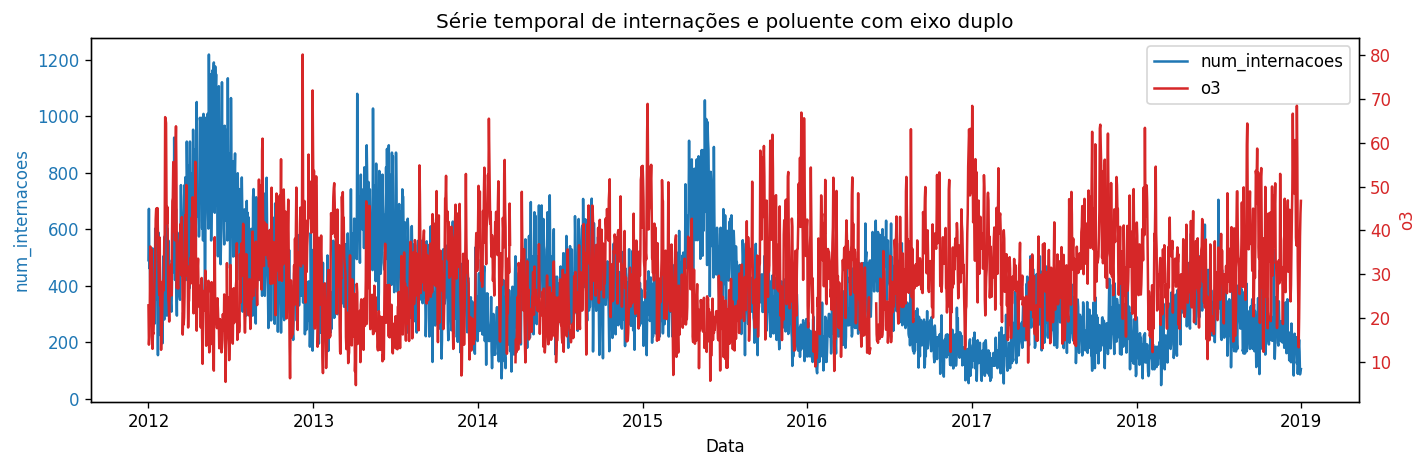

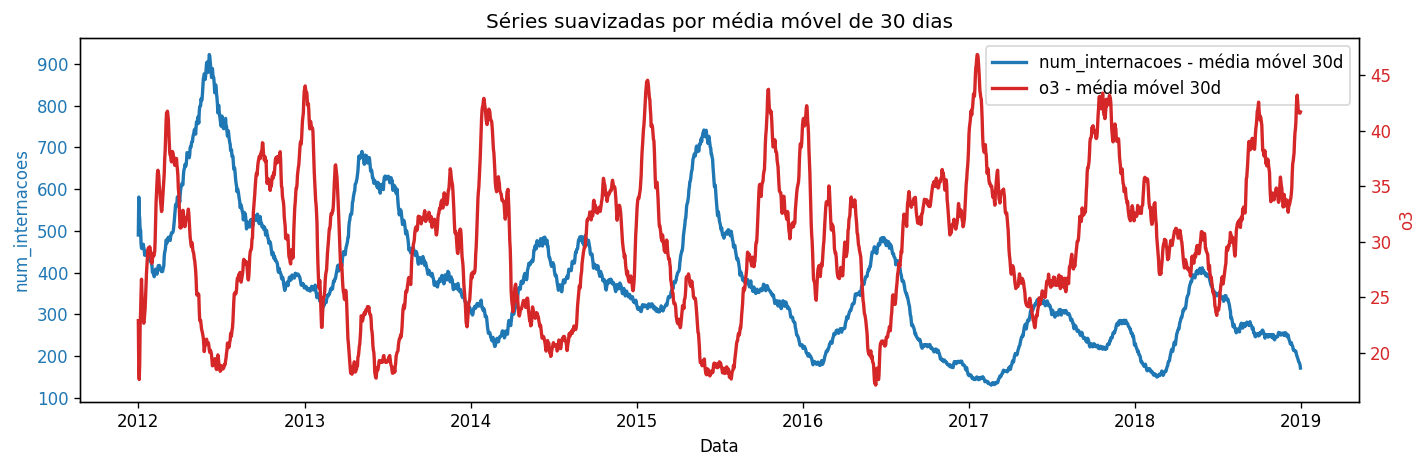

In [5]:
display(
    hospitalizations_and_air[[TARGET_COLUMN, ATMOSPHERIC_VARIABLE]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T.round(3)
)

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=FIG_DPI)

line1 = ax1.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air[TARGET_COLUMN],
    color="tab:blue",
    label=TARGET_COLUMN,
    linewidth=1.5,
)
ax1.set_xlabel("Data")
ax1.set_ylabel(TARGET_COLUMN, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
line2 = ax2.plot(
    hospitalizations_and_air[STANDARD_DATE_COLUMN],
    hospitalizations_and_air[ATMOSPHERIC_VARIABLE],
    color="tab:red",
    label=ATMOSPHERIC_VARIABLE,
    linewidth=1.5,
)
ax2.set_ylabel(ATMOSPHERIC_VARIABLE, color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Série temporal de internações e poluente com eixo duplo")
fig.tight_layout()
plt.show()

# Versão suavizada com média móvel para facilitar a leitura do comportamento global
plot_df = hospitalizations_and_air[[STANDARD_DATE_COLUMN, TARGET_COLUMN, ATMOSPHERIC_VARIABLE]].copy()
plot_df[f"{TARGET_COLUMN}_mm"] = plot_df[TARGET_COLUMN].rolling(ROLLING_MEAN_WINDOW, min_periods=1).mean()
plot_df[f"{ATMOSPHERIC_VARIABLE}_mm"] = plot_df[ATMOSPHERIC_VARIABLE].rolling(ROLLING_MEAN_WINDOW, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=FIG_DPI)

line1 = ax1.plot(
    plot_df[STANDARD_DATE_COLUMN],
    plot_df[f"{TARGET_COLUMN}_mm"],
    color="tab:blue",
    label=f"{TARGET_COLUMN} - média móvel {ROLLING_MEAN_WINDOW}d",
    linewidth=2,
)
ax1.set_xlabel("Data")
ax1.set_ylabel(TARGET_COLUMN, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
line2 = ax2.plot(
    plot_df[STANDARD_DATE_COLUMN],
    plot_df[f"{ATMOSPHERIC_VARIABLE}_mm"],
    color="tab:red",
    label=f"{ATMOSPHERIC_VARIABLE} - média móvel {ROLLING_MEAN_WINDOW}d",
    linewidth=2,
)
ax2.set_ylabel(ATMOSPHERIC_VARIABLE, color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title(f"Séries suavizadas por média móvel de {ROLLING_MEAN_WINDOW} dias")
fig.tight_layout()
plt.show()


## 6. Construção das features temporais do poluente

Nesta etapa, criamos:
- `lag0`: valor do poluente no mesmo dia;
- `lag1..lagMAX`: valores defasados do poluente;
- **médias móveis defasadas**, representando exposições acumuladas em diferentes janelas temporais e diferentes atrasos em relação ao dia das internações.

Para cada combinação de `window` e `shift`, a feature gerada resume o comportamento passado do poluente sem usar informação do próprio dia de referência.

Exemplo:
- `window = 7` e `shift = 1`: a média móvel usa os valores entre `t-7` e `t-1`;
- `window = 30` e `shift = 14`: a média móvel usa os valores entre `t-43` e `t-14`.


In [6]:
analysis_df = hospitalizations_and_air[[STANDARD_DATE_COLUMN, TARGET_COLUMN, ATMOSPHERIC_VARIABLE]].copy()
feature_metadata = []

# Valor contemporâneo (mesmo dia)
analysis_df["lag0"] = analysis_df[ATMOSPHERIC_VARIABLE]
feature_metadata.append(
    {
        "feature": "lag0",
        "feature_type": "lag",
        "lag_days": 0,
        "shift_days": 0,
        "window_size": 1,
        "description": "Valor do poluente no mesmo dia",
    }
)

# Lags simples
for lag in range(1, MAX_LAG + 1):
    feature_name = f"lag{lag}"
    analysis_df[feature_name] = analysis_df[ATMOSPHERIC_VARIABLE].shift(lag)
    feature_metadata.append(
        {
            "feature": feature_name,
            "feature_type": "lag",
            "lag_days": lag,
            "shift_days": lag,
            "window_size": 1,
            "description": f"Valor do poluente com defasagem de {lag} dia(s)",
        }
    )

# Médias móveis defasadas
for window in MOVING_AVERAGE_WINDOWS:
    for shift in SHIFTS:
        feature_name = f"ma_{window}d_shift_{shift}d"
        analysis_df[feature_name] = (
            analysis_df[ATMOSPHERIC_VARIABLE]
            .shift(shift)
            .rolling(window=window, min_periods=window)
            .mean()
        )
        feature_metadata.append(
            {
                "feature": feature_name,
                "feature_type": "media_movel_defasada",
                "lag_days": shift,
                "shift_days": shift,
                "window_size": window,
                "description": (
                    f"Média móvel de {window} dia(s) com shift de {shift} dia(s), "
                    f"resumindo a exposição entre t-{window + shift - 1} e t-{shift}"
                ),
            }
        )

feature_metadata = pd.DataFrame(feature_metadata)
feature_columns = feature_metadata["feature"].tolist()

## 7. Cálculo das correlações

Para cada feature temporal do poluente, calculamos as correlações com a série de internações usando:
- **Pearson**: sensível a relação linear;
- **Spearman**: sensível a relação monotônica e menos influenciado por outliers.


In [7]:
def safe_corr(series_x, series_y, method="pearson", min_obs=30):
    valid = series_x.notna() & series_y.notna()
    n_obs = int(valid.sum())
    if n_obs < min_obs:
        return np.nan, n_obs
    corr_value = series_x[valid].corr(series_y[valid], method=method)
    return corr_value, n_obs


corr_rows = []
for row in feature_metadata.to_dict(orient="records"):
    feature_name = row["feature"]

    pearson_value, n_obs = safe_corr(
        analysis_df[TARGET_COLUMN],
        analysis_df[feature_name],
        method="pearson",
        min_obs=MIN_OBS_FOR_CORR,
    )
    spearman_value, _ = safe_corr(
        analysis_df[TARGET_COLUMN],
        analysis_df[feature_name],
        method="spearman",
        min_obs=MIN_OBS_FOR_CORR,
    )

    corr_rows.append(
        {
            **row,
            "n_obs": n_obs,
            "pearson": pearson_value,
            "spearman": spearman_value,
        }
    )

corr_results = pd.DataFrame(corr_rows)
corr_results["abs_pearson"] = corr_results["pearson"].abs()
corr_results["abs_spearman"] = corr_results["spearman"].abs()

corr_results_sorted = corr_results.sort_values(
    by=["abs_spearman", "abs_pearson"],
    ascending=False,
).reset_index(drop=True)

## 8. Destaque das associações mais fortes

A tabela a seguir destaca as combinações com maiores correlações absolutas, facilitando a identificação de possíveis defasagens mais promissoras para etapas posteriores de modelagem.


In [8]:
TOP_N = 5

display(
    corr_results_sorted[
        [
            "feature",
            "feature_type",
            "description",
            "lag_days",
            "shift_days",
            "window_size",
            "n_obs",
            "pearson",
            "spearman",
            "abs_pearson",
            "abs_spearman",
        ]
    ]
    .head(TOP_N)
    .round(4)
)

lag_results = corr_results.query("feature_type == 'lag'").sort_values("lag_days").reset_index(drop=True)
ma_results = (
    corr_results
    .query("feature_type == 'media_movel_defasada'")
    .sort_values(["shift_days", "window_size"])
    .reset_index(drop=True)
)


,feature,feature_type,description,lag_days,shift_days,window_size,n_obs,pearson,spearman,abs_pearson,abs_spearman
0,ma_120d_shift_1d,media_movel_defasada,Média móvel de 120 dia(s) com shift de 1 dia(s...,1,1,120,2176,-0.4614,-0.5440,0.4614,0.5440
1,ma_120d_shift_7d,media_movel_defasada,Média móvel de 120 dia(s) com shift de 7 dia(s...,7,7,120,2170,-0.4343,-0.5242,0.4343,0.5242
2,ma_150d_shift_1d,media_movel_defasada,Média móvel de 150 dia(s) com shift de 1 dia(s...,1,1,150,2086,-0.4469,-0.5197,0.4469,0.5197
3,ma_90d_shift_1d,media_movel_defasada,Média móvel de 90 dia(s) com shift de 1 dia(s)...,1,1,90,2266,-0.4676,-0.5135,0.4676,0.5135
4,ma_90d_shift_7d,media_movel_defasada,Média móvel de 90 dia(s) com shift de 7 dia(s)...,7,7,90,2260,-0.4454,-0.5032,0.4454,0.5032


## 9. Visualização das correlações por lag

Esses gráficos ajudam a observar se a associação tende a se concentrar em algum atraso específico ou se o sinal fica mais forte quando usamos exposições acumuladas com diferentes janelas e shifts.


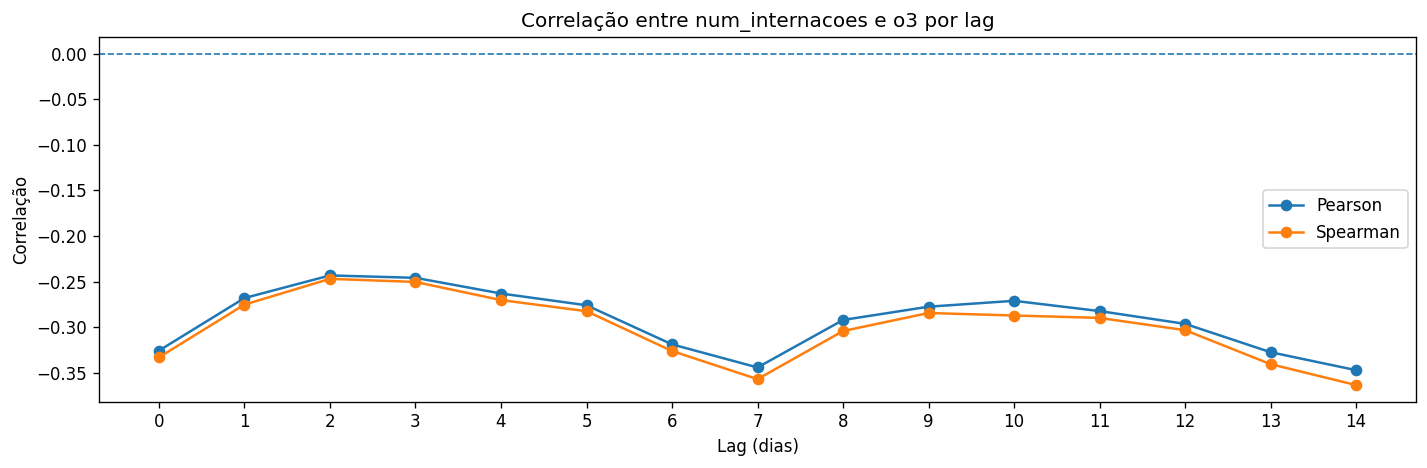

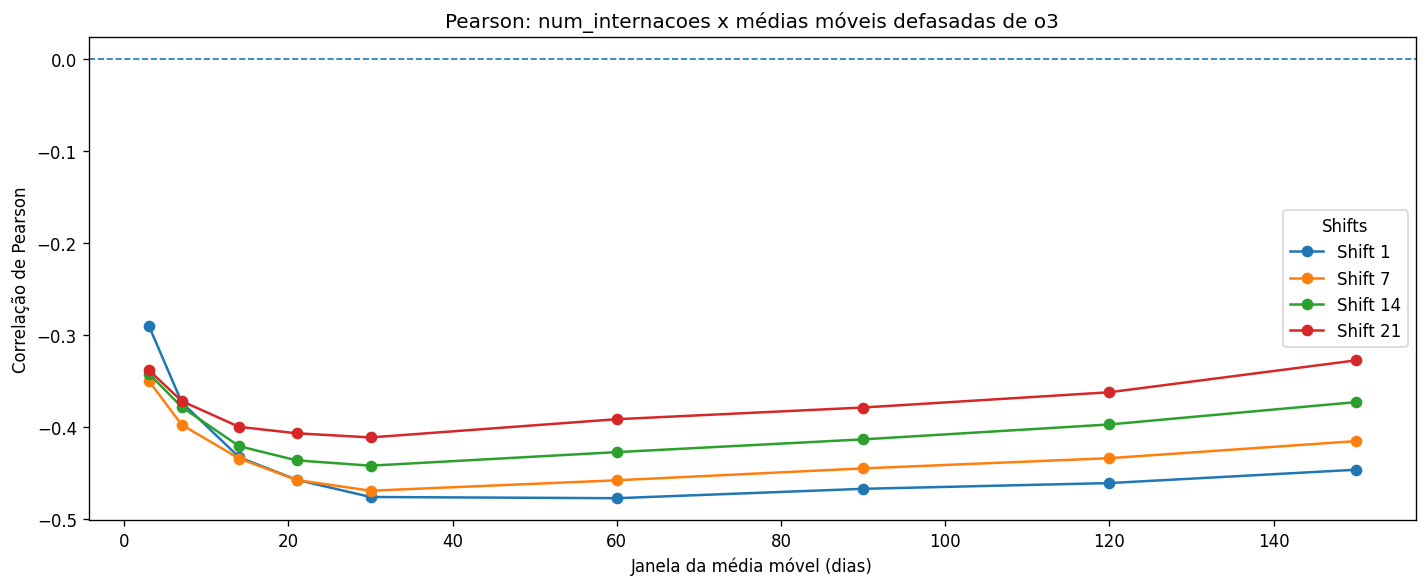

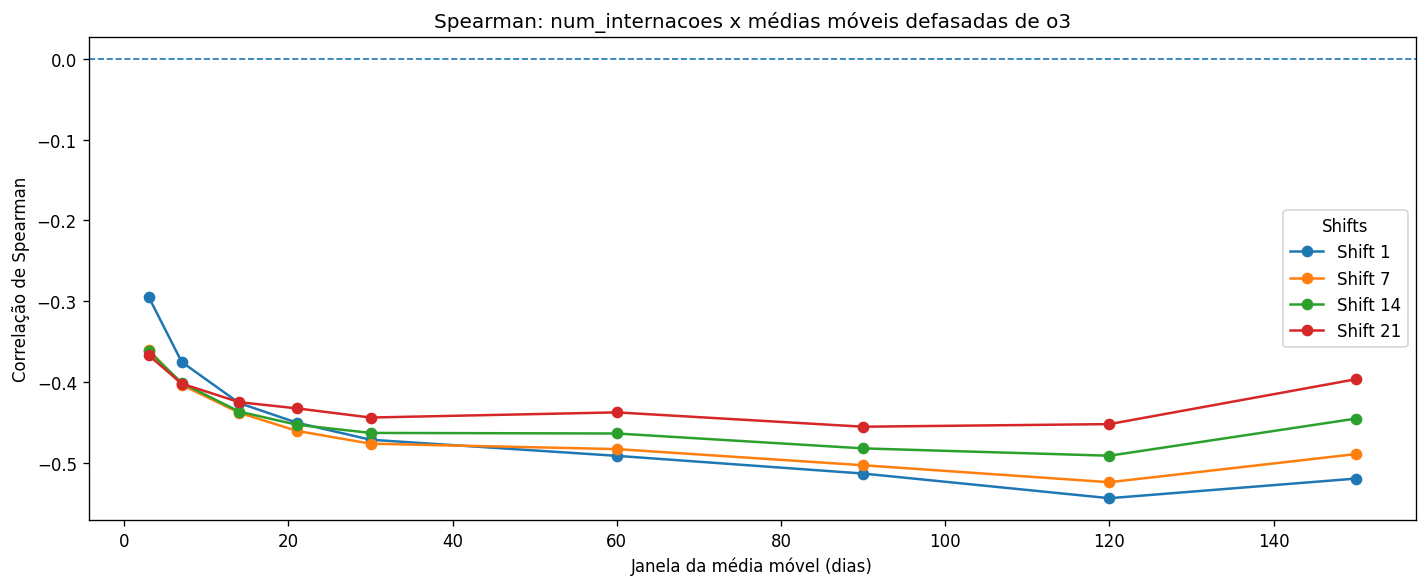

In [9]:
plt.figure(figsize=(12, 4), dpi=FIG_DPI)
plt.plot(lag_results["lag_days"], lag_results["pearson"], marker="o", label="Pearson")
plt.plot(lag_results["lag_days"], lag_results["spearman"], marker="o", label="Spearman")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(lag_results["lag_days"])
plt.xlabel("Lag (dias)")
plt.ylabel("Correlação")
plt.title(f"Correlação entre {TARGET_COLUMN} e {ATMOSPHERIC_VARIABLE} por lag")
plt.legend()
plt.tight_layout()
plt.show()

if not ma_results.empty:
    pearson_pivot = ma_results.pivot(index="window_size", columns="shift_days", values="pearson").sort_index()
    spearman_pivot = ma_results.pivot(index="window_size", columns="shift_days", values="spearman").sort_index()

    plt.figure(figsize=(12, 5), dpi=FIG_DPI)
    for shift in pearson_pivot.columns:
        plt.plot(
            pearson_pivot.index,
            pearson_pivot[shift],
            marker="o",
            label=f"Shift {int(shift)}"
        )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Janela da média móvel (dias)")
    plt.ylabel("Correlação de Pearson")
    plt.title(f"Pearson: {TARGET_COLUMN} x médias móveis defasadas de {ATMOSPHERIC_VARIABLE}")
    plt.legend(title="Shifts")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5), dpi=FIG_DPI)
    for shift in spearman_pivot.columns:
        plt.plot(
            spearman_pivot.index,
            spearman_pivot[shift],
            marker="o",
            label=f"Shift {int(shift)}"
        )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Janela da média móvel (dias)")
    plt.ylabel("Correlação de Spearman")
    plt.title(f"Spearman: {TARGET_COLUMN} x médias móveis defasadas de {ATMOSPHERIC_VARIABLE}")
    plt.legend(title="Shifts")
    plt.tight_layout()
    plt.show()


## 10. Síntese automática dos achados

Esta seção resume, de forma automática, quais combinações apresentaram os sinais mais fortes na análise de correlação. O objetivo é facilitar a interpretação e apontar candidatas para modelagem posterior.


In [10]:
def format_direction(value):
    if pd.isna(value):
        return "indefinida"
    return "positiva" if value > 0 else "negativa"

summary_lines = []

best_overall = corr_results_sorted.iloc[0]
summary_lines.append(
    "- A combinação com maior correlação absoluta na análise foi "
    f"`{best_overall['feature']}` ({best_overall['description'].lower()})."
)
summary_lines.append(
    f"  - Pearson = `{best_overall['pearson']:.4f}` ({format_direction(best_overall['pearson'])})"
)
summary_lines.append(
    f"  - Spearman = `{best_overall['spearman']:.4f}` ({format_direction(best_overall['spearman'])})"
)
summary_lines.append(
    f"  - Observações válidas = `{int(best_overall['n_obs'])}`"
)

best_lag = lag_results.sort_values(["abs_spearman", "abs_pearson"], ascending=False).iloc[0]
summary_lines.append(
    "- Entre os lags simples, o maior sinal ocorreu em "
    f"`{best_lag['feature']}` (defasagem de `{int(best_lag['lag_days'])}` dia(s))."
)
summary_lines.append(
    f"  - Pearson = `{best_lag['pearson']:.4f}` | Spearman = `{best_lag['spearman']:.4f}`"
)

if not ma_results.empty:
    best_ma = ma_results.sort_values(["abs_spearman", "abs_pearson"], ascending=False).iloc[0]
    summary_lines.append(
        "- Entre as médias móveis defasadas, o melhor resultado apareceu em "
        f"`{best_ma['feature']}` (janela de `{int(best_ma['window_size'])}` dias e shift de `{int(best_ma['shift_days'])}` dia(s))."
    )
    summary_lines.append(
        f"  - Pearson = `{best_ma['pearson']:.4f}` | Spearman = `{best_ma['spearman']:.4f}`"
    )

summary_lines.append(
    "- Esses resultados devem ser interpretados como evidência **exploratória** de associação e servem como insumo para etapas posteriores, como seleção de features, avaliação com lags candidatos e modelagem preditiva."
)

summary_md = "\n".join(summary_lines)
display(Markdown(summary_md))


- A combinação com maior correlação absoluta na análise foi `ma_120d_shift_1d` (média móvel de 120 dia(s) com shift de 1 dia(s), resumindo a exposição entre t-120 e t-1).
  - Pearson = `-0.4614` (negativa)
  - Spearman = `-0.5440` (negativa)
  - Observações válidas = `2176`
- Entre os lags simples, o maior sinal ocorreu em `lag14` (defasagem de `14` dia(s)).
  - Pearson = `-0.3472` | Spearman = `-0.3635`
- Entre as médias móveis defasadas, o melhor resultado apareceu em `ma_120d_shift_1d` (janela de `120` dias e shift de `1` dia(s)).
  - Pearson = `-0.4614` | Spearman = `-0.5440`
- Esses resultados devem ser interpretados como evidência **exploratória** de associação e servem como insumo para etapas posteriores, como seleção de features, avaliação com lags candidatos e modelagem preditiva.

## 11. Recomendação de feature para modelagem

Com base nos resultados para `o3`, a principal feature recomendada é:

- `o3_ma_120d_shift_1d`: média móvel de 120 dias com shift de 1 dia, resumindo a exposição entre `t-120` e `t-1`. Foi a combinação com maior sinal na análise (`Pearson = -0.4614`, `Spearman = -0.5440`) e indica que a informação mais relevante para `O3` apareceu em uma janela longa de exposição acumulada, com associação negativa.

Como candidata complementar, apenas se fizer sentido manter uma representação simples do poluente:

- `o3_lag14`: valor do poluente com defasagem de 14 dias. Foi o melhor lag simples (`Pearson = -0.3472`, `Spearman = -0.3635`), mas com sinal inferior ao de `o3_ma_120d_shift_1d`.

Não recomendo criar outras features de `O3` neste momento, porque as demais médias móveis longas ficaram relativamente próximas e tendem a ser redundantes. Como `O3` apresentou um sinal forte, mas negativo e concentrado em janelas longas, vale manter esse poluente como candidato importante e comparar seu ganho com os demais poluentes nas próximas etapas.
